# Projeto Académico de Aprendizagem Computacional

## Estudo Experimental de Validação Cruzada com Random Forest

Este notebook foi construído para realizar um **novo estudo experimental**, independente do notebook anterior, agora com um modelo **não linear**: `RandomForestRegressor`.

### Objetivo

Investigar se o comportamento das estratégias de validação:

- Hold-out (70/30)
- K-Fold CV (k = 10)
- Repeated K-Fold (10 folds, 5 repetições)

permanece consistente quando substituímos uma Regressão Linear por um algoritmo mais flexível e robusto.

### Hipótese experimental

Se a técnica de validação influencia de forma relevante a estimativa do erro, então essa sensibilidade deve continuar a aparecer mesmo com um modelo mais poderoso. Contudo, a **variabilidade entre folds** pode mudar devido à natureza não linear do Random Forest.


In [1]:
# Bibliotecas principais
from pathlib import Path
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, KFold, RepeatedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 6)


## 1. Configuração do problema

O dataset utilizado é o **Medical Cost Personal Datasets**, com objetivo de prever `charges`.

### Variáveis

- **Preditores numéricos:** `age`, `bmi`, `children`
- **Preditores categóricos:** `sex`, `smoker`, `region`
- **Alvo:** `charges`

O notebook usa uma função de localização do CSV para facilitar a execução em ambientes diferentes.


In [2]:
RANDOM_STATE = 42
TARGET = "charges"
NUMERIC_FEATURES = ["age", "bmi", "children"]
CATEGORICAL_FEATURES = ["sex", "smoker", "region"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES


def locate_dataset(filename: str = "insurance.csv") -> Path:
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd() / "trabalho" / "data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Não foi possível localizar {filename}. Verifique a pasta data/."
    )


DATA_PATH = locate_dataset()
DATA_PATH


WindowsPath('c:/Users/rodri/Documents/2semestre/AC/trabalho/data/insurance.csv')

## 2. Carregamento e inspeção inicial

Mesmo quando não existem valores omissos no CSV atual, a imputação continuará no pipeline. Isso é importante porque:

1. cumpre o requisito metodológico do projeto;
2. mantém o notebook robusto para futuras versões dos dados;
3. garante que o pré-processamento ocorre **dentro de cada fold**, evitando *data leakage*.


In [3]:
def load_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    expected_columns = set(ALL_FEATURES + [TARGET])
    missing_columns = expected_columns.difference(df.columns)
    if missing_columns:
        raise ValueError(f"Faltam colunas esperadas: {missing_columns}")
    return df


df = load_data(DATA_PATH)
display(df.head())

print(f"Dimensão do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
display(df.describe(include="all").T)
display(df.isna().sum().rename("missing_values").to_frame())


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9000,0,yes,southwest,"16,884.9240"
1,18,male,33.7700,1,no,southeast,"1,725.5523"
2,28,male,33.0000,3,no,southeast,"4,449.4620"
3,33,male,22.7050,0,no,northwest,"21,984.4706"
4,32,male,28.8800,0,no,northwest,"3,866.8552"


Dimensão do dataset: 1338 linhas x 7 colunas


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,"1,338.0000",NaN,NaN,NaN,39.2070,14.0500,18.0000,27.0000,39.0000,51.0000,64.0000
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,"1,338.0000",NaN,NaN,NaN,30.6634,6.0982,15.9600,26.2963,30.4000,34.6938,53.1300
children,"1,338.0000",NaN,NaN,NaN,1.0949,1.2055,0.0000,0.0000,1.0000,2.0000,5.0000
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,"1,338.0000",NaN,NaN,NaN,"13,270.4223","12,110.0112","1,121.8739","4,740.2872","9,382.0330","16,639.9125","63,770.4280"


,missing_values
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## 3. Pipeline de dados com `ColumnTransformer`

Para evitar vazamento de dados, todo o pré-processamento será encapsulado num `Pipeline` do `scikit-learn`.

### Etapas do pipeline

- **Numéricas**
  - imputação pela mediana;
  - escalonamento via `StandardScaler`.
- **Categóricas**
  - imputação pela moda;
  - codificação `OneHotEncoder`.
- **Modelo**
  - `RandomForestRegressor(n_estimators=100, random_state=42)`.

### Observação importante

Embora Random Forest não exija escalonamento para funcionar bem, o `StandardScaler` é mantido porque o enunciado exige explicitamente essa etapa e porque queremos um pipeline metodologicamente consistente com o estudo anterior.


In [4]:
def make_one_hot_encoder() -> OneHotEncoder:
    """Compatibilidade com versões diferentes do scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_pipeline(model_name: str = "random_forest") -> Pipeline:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, NUMERIC_FEATURES),
            ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )

    if model_name == "random_forest":
        model = RandomForestRegressor(
            n_estimators=100,
            random_state=RANDOM_STATE,
            n_jobs=1,
        )
    elif model_name == "linear_regression":
        model = LinearRegression()
    else:
        raise ValueError("Modelo não suportado.")

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )


rf_pipeline = build_pipeline("random_forest")
rf_pipeline


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 4. Funções auxiliares de avaliação

Para manter o código modular, definimos funções que:

- calculam métricas de desempenho;
- executam qualquer estratégia de reamostragem;
- armazenam métricas por split;
- calculam métricas agregadas a partir de todas as previsões fora da amostra.

Neste notebook, o desempenho será analisado apenas com:

- **MAE (Mean Absolute Error)**
- **RMSE (Root Mean Squared Error)**

Isso mantém a comparação objetiva e alinhada ao foco principal do estudo: observar como o protocolo de validação influencia a estimativa do erro do modelo.


In [5]:
def compute_metrics(y_true, y_pred) -> dict:
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
    }


def evaluate_resampling_strategy(
    X: pd.DataFrame,
    y: pd.Series,
    split_iterator,
    technique_name: str,
    model_name: str,
) -> tuple[pd.DataFrame, dict]:
    split_rows = []
    pooled_truth = []
    pooled_pred = []
    base_estimator = build_pipeline(model_name=model_name)

    for iteration, (train_idx, test_idx) in enumerate(split_iterator, start=1):
        model = clone(base_estimator)

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        pooled_truth.extend(y_test.to_numpy())
        pooled_pred.extend(np.asarray(y_pred))

        row = compute_metrics(y_test, y_pred)
        row["Technique"] = technique_name
        row["Iteration"] = iteration
        row["TestSize"] = len(test_idx)
        split_rows.append(row)

    split_df = pd.DataFrame(split_rows)
    pooled_metrics = compute_metrics(np.array(pooled_truth), np.array(pooled_pred))
    pooled_metrics["Technique"] = technique_name
    pooled_metrics["n_splits"] = len(split_df)
    pooled_metrics["n_predictions"] = len(pooled_truth)

    return split_df, pooled_metrics


def evaluate_holdout(
    X: pd.DataFrame,
    y: pd.Series,
    model_name: str,
) -> tuple[pd.DataFrame, dict]:
    train_idx, test_idx = train_test_split(
        np.arange(len(X)),
        test_size=0.30,
        random_state=RANDOM_STATE,
    )
    return evaluate_resampling_strategy(
        X=X,
        y=y,
        split_iterator=[(train_idx, test_idx)],
        technique_name="Hold-out (70/30)",
        model_name=model_name,
    )


def run_validation_study(
    X: pd.DataFrame,
    y: pd.Series,
    model_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    strategies = [
        ("Hold-out (70/30)", None),
        ("K-Fold CV (10)", KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE).split(X, y)),
        (
            "Repeated K-Fold (10x5)",
            RepeatedKFold(n_splits=10, n_repeats=5, random_state=RANDOM_STATE).split(X, y),
        ),
    ]

    split_results = []
    pooled_results = []

    for technique_name, splitter in strategies:
        start_time = time.time()

        if technique_name == "Hold-out (70/30)":
            split_df, pooled_metrics = evaluate_holdout(X, y, model_name=model_name)
        else:
            split_df, pooled_metrics = evaluate_resampling_strategy(
                X=X,
                y=y,
                split_iterator=splitter,
                technique_name=technique_name,
                model_name=model_name,
            )

        elapsed = time.time() - start_time
        print(f"{model_name} | {technique_name} concluída em {elapsed:.2f} s")

        split_results.append(split_df)
        pooled_results.append(pooled_metrics)

    return pd.concat(split_results, ignore_index=True), pd.DataFrame(pooled_results)


def build_summary_table(
    split_df: pd.DataFrame,
    pooled_df: pd.DataFrame,
) -> pd.DataFrame:
    summary = (
        split_df.groupby("Technique")
        .agg(
            MAE_mean=("MAE", "mean"),
            MAE_std=("MAE", "std"),
            RMSE_mean=("RMSE", "mean"),
            RMSE_std=("RMSE", "std"),
            n_evaluations=("Iteration", "count"),
        )
        .reset_index()
    )

    summary = summary.merge(
        pooled_df[["Technique", "MAE", "RMSE"]],
        on="Technique",
        how="left",
        suffixes=("_split", "_pooled"),
    )

    summary = summary.rename(
        columns={
            "MAE": "MAE_pooled",
            "RMSE": "RMSE_pooled",
        }
    )

    return summary.sort_values("MAE_pooled").reset_index(drop=True)


## 5. Execução do estudo com Random Forest

Nesta secção executamos o estudo principal com `RandomForestRegressor(n_estimators=100, random_state=42)`.

Ao restringir a análise a Hold-out, K-Fold e Repeated K-Fold, o notebook mantém as estratégias centrais do estudo e reduz significativamente o tempo de execução, preservando o foco na comparação da estabilidade das estimativas de erro.


In [6]:
X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

rf_split_results, rf_pooled_results = run_validation_study(
    X=X,
    y=y,
    model_name="random_forest",
)

rf_summary = build_summary_table(rf_split_results, rf_pooled_results)

display(rf_split_results.head())
display(rf_pooled_results)
display(rf_summary)


random_forest | Hold-out (70/30) concluída em 1.02 s
random_forest | K-Fold CV (10) concluída em 10.18 s
random_forest | Repeated K-Fold (10x5) concluída em 46.17 s


,MAE,RMSE,Technique,Iteration,TestSize
0,"2,566.6153","4,610.8662",Hold-out (70/30),1,402
1,"2,517.8152","4,717.7564",K-Fold CV (10),1,134
2,"2,579.6432","4,691.9272",K-Fold CV (10),2,134
3,"2,509.5617","4,482.8496",K-Fold CV (10),3,134
4,"2,858.2297","5,209.4101",K-Fold CV (10),4,134


,MAE,RMSE,Technique,n_splits,n_predictions
0,"2,566.6153","4,610.8662",Hold-out (70/30),1,402
1,"2,692.9534","4,897.2444",K-Fold CV (10),10,1338
2,"2,653.9076","4,834.6341",Repeated K-Fold (10x5),50,6690


,Technique,MAE_mean,MAE_std,RMSE_mean,RMSE_std,n_evaluations,MAE_pooled,RMSE_pooled
0,Hold-out (70/30),"2,566.6153",NaN,"4,610.8662",NaN,1,"2,566.6153","4,610.8662"
1,Repeated K-Fold (10x5),"2,654.0227",350.3578,"4,784.3296",703.8731,50,"2,653.9076","4,834.6341"
2,K-Fold CV (10),"2,693.0911",170.1834,"4,878.2450",460.1210,10,"2,692.9534","4,897.2444"


## 6. Tabela resumo e leitura inicial

A tabela abaixo resume:

- média e desvio padrão do `MAE` e do `RMSE` por split;
- métricas agregadas com base em todas as previsões fora da amostra.

Esta organização ajuda a analisar simultaneamente:

- o nível médio de desempenho;
- a estabilidade da técnica;
- a variabilidade introduzida pelo protocolo de validação.


In [7]:
rf_summary


,Technique,MAE_mean,MAE_std,RMSE_mean,RMSE_std,n_evaluations,MAE_pooled,RMSE_pooled
0,Hold-out (70/30),"2,566.6153",NaN,"4,610.8662",NaN,1,"2,566.6153","4,610.8662"
1,Repeated K-Fold (10x5),"2,654.0227",350.3578,"4,784.3296",703.8731,50,"2,653.9076","4,834.6341"
2,K-Fold CV (10),"2,693.0911",170.1834,"4,878.2450",460.1210,10,"2,692.9534","4,897.2444"


## 7. Boxplot do MAE para o Random Forest

O boxplot do `MAE` ajuda a identificar:

- dispersão entre folds;
- assimetria dos erros;
- técnicas com estimativas possivelmente mais otimistas;
- diferenças entre validações únicas e validações repetidas.


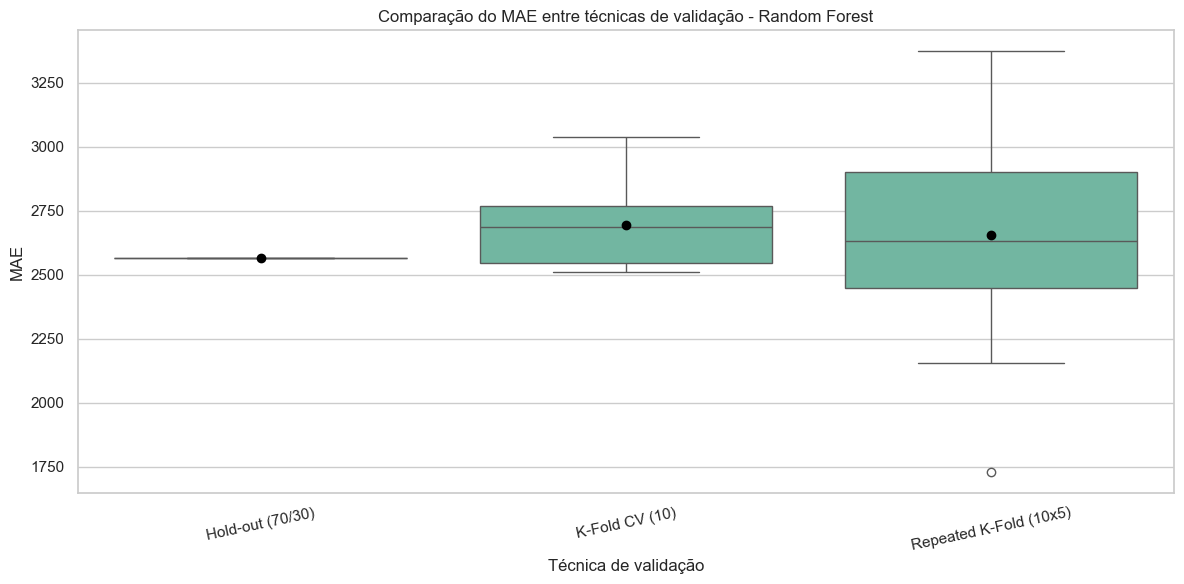

In [8]:
plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=rf_split_results,
    x="Technique",
    y="MAE",
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 6,
    },
)
ax.set_title("Comparação do MAE entre técnicas de validação - Random Forest")
ax.set_xlabel("Técnica de validação")
ax.set_ylabel("MAE")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()


## 8. Comparação com uma Regressão Linear simples

Para que a discussão final não dependa do notebook anterior, calculamos aqui uma **linha de base interna** com `LinearRegression`, usando exatamente as mesmas funções, o mesmo pipeline e as mesmas estratégias de validação.

Assim, a comparação entre variabilidade passa a ser feita no mesmo ambiente experimental, agora focando apenas em **MAE** e **RMSE**.


In [9]:
linear_split_results, linear_pooled_results = run_validation_study(
    X=X,
    y=y,
    model_name="linear_regression",
)

linear_summary = build_summary_table(linear_split_results, linear_pooled_results)

display(linear_summary)


linear_regression | Hold-out (70/30) concluída em 0.08 s
linear_regression | K-Fold CV (10) concluída em 0.77 s
linear_regression | Repeated K-Fold (10x5) concluída em 2.25 s


,Technique,MAE_mean,MAE_std,RMSE_mean,RMSE_std,n_evaluations,MAE_pooled,RMSE_pooled
0,Hold-out (70/30),"4,145.4506",NaN,"5,812.1003",NaN,1,"4,145.4506","5,812.1003"
1,Repeated K-Fold (10x5),"4,203.9652",417.2952,"6,055.7441",641.4425,50,"4,203.7421","6,088.7246"
2,K-Fold CV (10),"4,204.6377",280.1639,"6,070.3504",436.0309,10,"4,204.8275","6,084.1872"


In [10]:
variability_comparison = rf_summary.merge(
    linear_summary,
    on="Technique",
    suffixes=("_rf", "_linear"),
)

comparison_table = variability_comparison[
    [
        "Technique",
        "MAE_std_rf",
        "MAE_std_linear",
        "RMSE_std_rf",
        "RMSE_std_linear",
        "MAE_pooled_rf",
        "MAE_pooled_linear",
        "RMSE_pooled_rf",
        "RMSE_pooled_linear",
    ]
].copy()

display(comparison_table)


,Technique,MAE_std_rf,MAE_std_linear,RMSE_std_rf,RMSE_std_linear,MAE_pooled_rf,MAE_pooled_linear,RMSE_pooled_rf,RMSE_pooled_linear
0,Hold-out (70/30),NaN,NaN,NaN,NaN,"2,566.6153","4,145.4506","4,610.8662","5,812.1003"
1,Repeated K-Fold (10x5),350.3578,417.2952,703.8731,641.4425,"2,653.9076","4,203.7421","4,834.6341","6,088.7246"
2,K-Fold CV (10),170.1834,280.1639,460.1210,436.0309,"2,692.9534","4,204.8275","4,897.2444","6,084.1872"


In [11]:
def compare_variability_text(rf_summary: pd.DataFrame, linear_summary: pd.DataFrame) -> str:
    merged = rf_summary.merge(linear_summary, on="Technique", suffixes=("_rf", "_linear"))
    lines = ["### Síntese automática da comparação RF vs. Regressão Linear", ""]

    for _, row in merged.iterrows():
        technique = row["Technique"]
        rf_std = row["MAE_std_rf"]
        lin_std = row["MAE_std_linear"]

        if pd.isna(rf_std) and pd.isna(lin_std):
            variability_sentence = "ambos têm apenas uma avaliação, logo não há desvio padrão comparável."
        elif pd.isna(rf_std):
            variability_sentence = "o desvio padrão do Random Forest não está disponível nesta técnica."
        elif pd.isna(lin_std):
            variability_sentence = "o desvio padrão da Regressão Linear não está disponível nesta técnica."
        elif rf_std < lin_std:
            variability_sentence = (
                f"o Random Forest apresentou menor variabilidade de MAE "
                f"({rf_std:.2f} vs. {lin_std:.2f})."
            )
        elif rf_std > lin_std:
            variability_sentence = (
                f"o Random Forest apresentou maior variabilidade de MAE "
                f"({rf_std:.2f} vs. {lin_std:.2f})."
            )
        else:
            variability_sentence = "os dois modelos apresentaram variabilidade de MAE muito semelhante."

        lines.append(f"- **{technique}**: {variability_sentence}")

    return "\n".join(lines)


display(Markdown(compare_variability_text(rf_summary, linear_summary)))


### Síntese automática da comparação RF vs. Regressão Linear

- **Hold-out (70/30)**: ambos têm apenas uma avaliação, logo não há desvio padrão comparável.
- **Repeated K-Fold (10x5)**: o Random Forest apresentou menor variabilidade de MAE (350.36 vs. 417.30).
- **K-Fold CV (10)**: o Random Forest apresentou menor variabilidade de MAE (170.18 vs. 280.16).

## 9. Discussão final: variabilidade do Random Forest face à Regressão Linear

Ao comparar os desvios padrão das métricas entre os dois modelos, a leitura esperada é a seguinte:

- se o **Random Forest** apresentar **menor desvio padrão** entre folds, isso sugere que o modelo é mais estável perante mudanças de partição e que a sua natureza não linear capturou melhor as relações do dataset sem depender tanto da divisão específica;
- se apresentar **maior desvio padrão**, isso indica que o ganho de flexibilidade veio acompanhado de maior sensibilidade às amostras de treino, o que pode refletir maior oscilação da fronteira de decisão/regressão entre folds;
- se o **Hold-out** parecer melhor do que as técnicas repetidas, isso deve ser interpretado com cautela, porque uma única divisão pode produzir uma estimativa mais otimista;
- se **K-Fold** e **Repeated K-Fold** convergirem para valores próximos, isso reforça a ideia de que a estimativa de erro está mais estável e menos dependente do protocolo.

### Interpretação metodológica

Num problema como o de previsão de custos médicos, é plausível que o Random Forest:

- reduza o erro médio em relação à Regressão Linear;
- lide melhor com relações não lineares e interações implícitas entre variáveis;
- apresente comportamento mais robusto nas métricas centrais;
- mas ainda assim continue sensível ao tipo de validação usado.

Portanto, este estudo permite verificar se a conclusão inspirada em Tougui et al. se mantém: **a técnica de validação influencia a estimativa de desempenho mesmo quando utilizamos um modelo mais poderoso e não linear**.
